# Датасет

In [13]:
import pandas as pd

phrases = pd.read_csv('simpsons_script_lines.csv', 
                      on_bad_lines='skip', 
                      usecols=['character_id', 'normalized_text'],
                     )
print(phrases.head())

  character_id                                    normalized_text
0        464.0  no actually it was a little of both sometimes ...
1          9.0                                wheres mr bergstrom
2        464.0  i dont know although id sure like to talk to h...
3          9.0                          that life is worth living
4         40.0  the polls will be open from now until the end ...


/var/folders/ds/69y_yy712js2_g3r477nw9s40000gn/T/ipykernel_41406/3652320053.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  phrases = pd.read_csv('simpsons_script_lines.csv',


In [16]:
phrases['character_id'] = pd.to_numeric(phrases['character_id'], errors='coerce').astype('Int64')

In [17]:
characters = pd.read_csv('simpsons_characters.csv', on_bad_lines='skip', usecols=['id', 'normalized_name'])
print(characters.head())

   id   normalized_name
0   7          children
1  12  mechanical santa
2  13        tattoo man
3  16  doctor zitsofsky
4  20          students


In [20]:
dataset = pd.merge(
    phrases, 
    characters, 
    left_on='character_id', 
    right_on='id', 
    how='left'
)
dataset = dataset.drop(columns=['character_id'])
dataset = dataset.drop(columns=['id'])
dataset.head()

,normalized_text,normalized_name
0,no actually it was a little of both sometimes ...,miss hoover
1,wheres mr bergstrom,lisa simpson
2,i dont know although id sure like to talk to h...,miss hoover
3,that life is worth living,lisa simpson
4,the polls will be open from now until the end ...,edna krabappel-flanders


# Модель

In [21]:
from gensim import models

In [30]:
sentences = []
for _, row in dataset.iterrows():
    try:
        sentences.append(row['normalized_text'].split(' '))
    except AttributeError:
        pass

In [32]:
model = models.Word2Vec()
model.build_vocab(sentences)
model.train(sentences, total_examples=model.corpus_count, epochs=model.epochs)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(4776843, 6530465)

# Визуализация

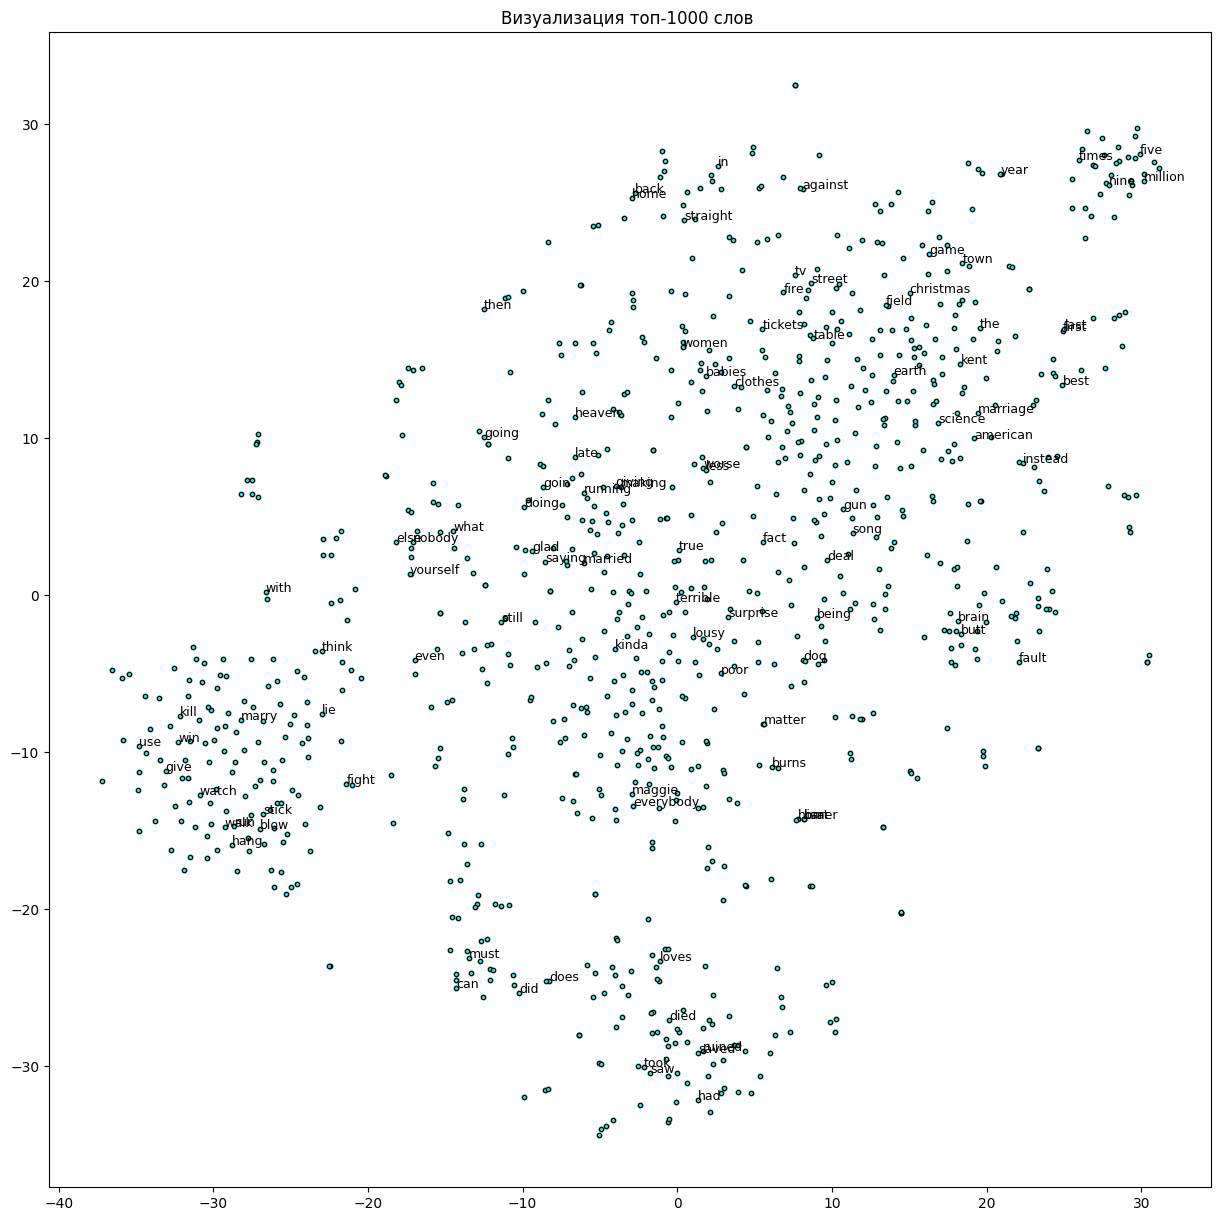

In [35]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

words = model.wv.index_to_key[:1000]
vectors = model.wv.vectors[:1000]
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
vectors_2d = tsne.fit_transform(vectors)


plt.figure(figsize=(15, 15))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], edgecolors='k', c='cyan', s=10)
for i, word in enumerate(words):
    if i % 10 == 0: # подписываем только часть слов для читаемости
        plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=9)

plt.title("Визуализация топ-1000 слов ")
plt.show()

# Арифметика

In [36]:
# homer - marge + bart
result = model.wv.most_similar(positive=['homer', 'bart'], negative=['marge'], topn=3)

for word, score in result:
    print(f"{word}: {score:.4f}")

lisa: 0.7228
grampa: 0.6781
milhouse: 0.6157


Лиза в топе - хороший результат.

In [43]:
# bart - lisa + school
result = model.wv.most_similar(positive=['bart', 'school'], negative=['lisa'], topn=3)

for word, score in result:
    print(f"{word}: {score:.4f}")

church: 0.6832
house: 0.6676
game: 0.6663


Церковь в топе - наврное, неплохой результат для Лизы.

In [39]:
# marge - homer + home
result = model.wv.most_similar(positive=['marge', 'home'], negative=['homer'], topn=3)

for word, score in result:
    print(f"{word}: {score:.4f}")

back: 0.7192
sleep: 0.6215
bed: 0.6160


в третьем эксперименте результат странный.